# Fiona Usage Analytics

Weekly and longitudinal analysis of chatbot interactions and feedback.

In [1]:
# SPDX-License-Identifier: Apache-2.0
# Licensed to the Ed-Fi Alliance under one or more agreements.
# The Ed-Fi Alliance licenses this file to you under the Apache License, Version 2.0.
# See the LICENSE and NOTICES files in the project root for more information.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.1f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Set to None to include all deployment types
DEPLOYMENT_FILTER = 'production'

## Optional Bootstrap: Export Source Data From Azure Cosmos DB

Use this section to pull fresh interactions and feedback documents from Cosmos DB into local CSV files that the rest of this notebook already expects.

Required environment variables:
- `COSMOS_ENDPOINT`
- `COSMOS_KEY`
- `COSMOS_DATABASE`

Optional environment variables:
- `COSMOS_INTERACTIONS_CONTAINER` (default: `chatbot-interactions`)
- `COSMOS_FEEDBACK_CONTAINER` (default: `chatbot-feedback`)
- `COSMOS_MAX_ITEMS` (default: `250000`)
- `RUN_COSMOS_EXPORT` (`true` or `false`, default: `false`)

In [4]:
import os
from dotenv import load_dotenv
from pathlib import Path

# Load .env file from current notebook directory
env_file = Path.cwd() / ".env"
if env_file.exists():
    load_dotenv(env_file)
    print(f"✓ Loaded .env file from: {env_file}")
else:
    print(f"⚠ No .env file found at: {env_file}")
    print(f"  Current working directory: {Path.cwd()}")

# Verify required environment variables
required_vars = ["COSMOS_ENDPOINT", "COSMOS_KEY", "COSMOS_DATABASE"]
optional_vars = [
    "COSMOS_INTERACTION_CONTAINER",
    "COSMOS_FEEDBACK_CONTAINER",
    "COSMOS_MAX_ITEMS",
    "RUN_COSMOS_EXPORT",
]

print("\n" + "=" * 60)
print("ENVIRONMENT VARIABLES VERIFICATION")
print("=" * 60)

missing_required = []
for var in required_vars:
    value = os.getenv(var)
    if value:
        # Mask sensitive values
        if "KEY" in var:
            masked = value[:10] + "..." + value[-10:] if len(value) > 20 else "***"
            print(f"✓ {var}: {masked}")
        else:
            print(f"✓ {var}: {value}")
    else:
        print(f"✗ {var}: NOT SET")
        missing_required.append(var)

print("\nOptional variables:")
for var in optional_vars:
    value = os.getenv(var)
    if value:
        print(f"✓ {var}: {value}")
    else:
        print(f"  {var}: (not set, will use default)")

print("=" * 60)

if missing_required:
    print(f"\n⚠ WARNING: Missing required variables: {', '.join(missing_required)}")
    print("The Cosmos export will fail if these are not set.")
else:
    print("\n✓ All required environment variables are set!")
    print("Ready to run Cosmos export.")

python-dotenv could not parse statement starting at line 2
python-dotenv could not parse statement starting at line 3
python-dotenv could not parse statement starting at line 4
python-dotenv could not parse statement starting at line 5


✓ Loaded .env file from: c:\Dev\local-ed-fi\Fiona\notebooks\usage-analytics\.env

ENVIRONMENT VARIABLES VERIFICATION
✓ COSMOS_ENDPOINT: https://fiona-db-dev-cosmos.documents.azure.com:443/
✓ COSMOS_KEY: D1l1FyUrEr...DbbL5D0w==
✓ COSMOS_DATABASE: chatbot

Optional variables:
✓ COSMOS_INTERACTION_CONTAINER: interactions
✓ COSMOS_FEEDBACK_CONTAINER: feedback
  COSMOS_MAX_ITEMS: (not set, will use default)
✓ RUN_COSMOS_EXPORT: true

✓ All required environment variables are set!
Ready to run Cosmos export.


In [5]:
import os
import csv
from pathlib import Path

# Load .env file to get Cosmos credentials
from dotenv import load_dotenv
load_dotenv()

INTERACTIONS_CSV_FILE = "chatbot_interactions_query_result.csv"
FEEDBACK_CSV_FILE = "chatbot_feedback_query_result.csv"


def _normalize_records(records):
    if not records:
        return pd.DataFrame()

    df = pd.json_normalize(records)

    # Drop Cosmos metadata fields that are not needed in analysis.
    drop_cols = [c for c in ["_rid", "_self", "_etag", "_attachments", "_ts"] if c in df.columns]
    if drop_cols:
        df = df.drop(columns=drop_cols)

    # Ensure datetime-like fields are serialized cleanly for CSV.
    for col in ["timestamp", "createdAt", "updatedAt"]:
        if col in df.columns:
            try:
                # Convert to datetime with coercion, then to string
                df[col] = pd.to_datetime(df[col], errors="coerce", utc=True).astype(str)
            except Exception as e:
                print(f"Warning: Could not convert {col} to datetime: {e}")
                # Keep the column as-is if conversion fails
                df[col] = df[col].astype(str)

    return df


def _export_container_to_csv(container_client, csv_path, deployment_filter=None, max_items=250000):
    query = "SELECT TOP @maxItems * FROM c"
    params = [{"name": "@maxItems", "value": int(max_items)}]

    if deployment_filter:
        query += " WHERE c.deploymentType = @deploymentType"
        params.append({"name": "@deploymentType", "value": deployment_filter})

    rows = list(
        container_client.query_items(
            query=query,
            parameters=params,
            enable_cross_partition_query=True,
        )
    )

    df = _normalize_records(rows)
    # Use QUOTE_ALL to ensure all fields are quoted, preventing parsing issues with newlines/quotes
    df.to_csv(csv_path, index=False, sep=";", quotechar='"', quoting=csv.QUOTE_ALL)
    return len(df), list(df.columns)


run_cosmos_export = os.getenv("RUN_COSMOS_EXPORT", "false").lower() == "true"

if run_cosmos_export:
    from azure.cosmos import CosmosClient

    endpoint = os.getenv("COSMOS_ENDPOINT")
    key = os.getenv("COSMOS_KEY")
    database_name = os.getenv("COSMOS_DATABASE")

    missing = [
        name
        for name, value in {
            "COSMOS_ENDPOINT": endpoint,
            "COSMOS_KEY": key,
            "COSMOS_DATABASE": database_name,
        }.items()
        if not value
    ]

    if missing:
        raise ValueError(f"Missing required environment variables: {', '.join(missing)}")

    interactions_container_name = os.getenv("COSMOS_INTERACTION_CONTAINER", "chatbot_interactions")
    feedback_container_name = os.getenv("COSMOS_FEEDBACK_CONTAINER", "chatbot_feedback")
    max_items = int(os.getenv("COSMOS_MAX_ITEMS", "250000"))

    client = CosmosClient(endpoint, credential=key)
    db = client.get_database_client(database_name)

    interactions_container = db.get_container_client(interactions_container_name)
    feedback_container = db.get_container_client(feedback_container_name)

    ix_count, ix_cols = _export_container_to_csv(
        interactions_container,
        INTERACTIONS_CSV_FILE,
        deployment_filter=DEPLOYMENT_FILTER,
        max_items=max_items,
    )
    fb_count, fb_cols = _export_container_to_csv(
        feedback_container,
        FEEDBACK_CSV_FILE,
        deployment_filter=DEPLOYMENT_FILTER,
        max_items=max_items,
    )

    print(f"Exported interactions CSV: {INTERACTIONS_CSV_FILE} ({ix_count} rows, {len(ix_cols)} cols)")
    print(f"Exported feedback CSV: {FEEDBACK_CSV_FILE} ({fb_count} rows, {len(fb_cols)} cols)")
else:
    print("Skipping Cosmos export. Set RUN_COSMOS_EXPORT=true to export fresh data from Cosmos DB.")
    print(f"Notebook will read local files: {INTERACTIONS_CSV_FILE}, {FEEDBACK_CSV_FILE}")

python-dotenv could not parse statement starting at line 2
python-dotenv could not parse statement starting at line 3
python-dotenv could not parse statement starting at line 4
python-dotenv could not parse statement starting at line 5


Exported interactions CSV: chatbot_interactions_query_result.csv (232 rows, 12 cols)
Exported feedback CSV: chatbot_feedback_query_result.csv (23 rows, 10 cols)


## Load Data

In [6]:
ix_raw = pd.read_csv(
    INTERACTIONS_CSV_FILE,
    sep=';', quotechar='"', dtype=str,
    on_bad_lines='skip',  # Skip any malformed rows
    engine='python',  # Use Python engine for better handling of complex CSVs
)
ix_raw.columns = [c.strip('"').lstrip('/') for c in ix_raw.columns]
ix = ix_raw.copy()
for col in ['deploymentType', 'userId', 'teamId', 'channelId', 'threadTs',
            'messageTs', 'interactionType', 'status', 'errorType', 'rateLimited']:
    if col in ix.columns:
        ix[col] = ix[col].str.strip('"')
ix['timestamp'] = pd.to_datetime(ix['timestamp'].str.strip('"'), utc=True).dt.tz_convert('US/Central')
ix['rateLimited'] = ix['rateLimited'].str.lower() == 'true'
ix['is_error'] = ix['status'] == 'error'
ix['date'] = ix['timestamp'].dt.date
# W-SUN: period ends Sunday, start_time gives Monday
ix['week_start'] = ix['timestamp'].dt.to_period('W-SUN').apply(lambda p: p.start_time.date())
if DEPLOYMENT_FILTER:
    ix = ix[ix['deploymentType'] == DEPLOYMENT_FILTER].copy()
print(f"Interactions loaded from {INTERACTIONS_CSV_FILE}: {len(ix)} rows, {ix['date'].nunique()} days, {ix['userId'].nunique()} unique users")
display(ix.dtypes)

Interactions loaded from chatbot_interactions_query_result.csv: 232 rows, 26 days, 25 unique users


id                                        str
userId                                    str
teamId                                    str
channelId                                 str
threadTs                                  str
messageTs                                 str
interactionType                           str
status                                    str
errorType                                 str
rateLimited                              bool
deploymentType                            str
timestamp          datetime64[us, US/Central]
is_error                                 bool
date                                   object
week_start                             object
dtype: object

In [7]:
fb_raw = pd.read_csv(
    FEEDBACK_CSV_FILE,
    sep=';', quotechar='"', dtype=str,
    on_bad_lines='skip',  # Skip any malformed rows
    engine='python',  # Use Python engine for better handling of complex CSVs
)
fb_raw.columns = [c.strip('"').lstrip('/') for c in fb_raw.columns]
fb = fb_raw.copy()
for col in ['deploymentType', 'feedbackId', 'userId', 'channelId', 'messageTs', 'value', 'userMessage', 'botResponse']:
    if col in fb.columns:
        fb[col] = fb[col].str.strip('"')
fb['timestamp'] = pd.to_datetime(fb['timestamp'].str.strip('"'), utc=True).dt.tz_convert('US/Central')
fb['is_good'] = fb['value'] == 'good-feedback'
fb['is_bad'] = fb['value'] == 'bad-feedback'
fb['date'] = fb['timestamp'].dt.date
fb['week_start'] = fb['timestamp'].dt.to_period('W-SUN').apply(lambda p: p.start_time.date())
if DEPLOYMENT_FILTER:
    fb = fb[fb['deploymentType'] == DEPLOYMENT_FILTER].copy()
print(f"Feedback loaded from {FEEDBACK_CSV_FILE}: {len(fb)} rows")
display(fb['value'].value_counts())

Feedback loaded from chatbot_feedback_query_result.csv: 23 rows


value
good-feedback    17
bad-feedback      6
Name: count, dtype: int64

## Helper Functions

In [8]:
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

def week_label(d):
    end = d + pd.Timedelta(days=6)
    start_str = f"{MONTHS[d.month-1]} {d.day}"
    end_str = f"{MONTHS[end.month-1]} {end.day}, {end.year}"
    return f"{start_str}-{end_str}"


def compute_weekly(interactions, feedback):
    weekly_ix = interactions.groupby('week_start').agg(
        unique_users=('userId', 'nunique'),
        sessions=('threadTs', 'nunique'),
        total_interactions=('id', 'count'),
        errors=('is_error', 'sum'),
        rate_limited=('rateLimited', 'sum'),
    ).reset_index()
    weekly_fb = feedback.groupby('week_start').agg(
        good_feedback=('is_good', 'sum'),
        bad_feedback=('is_bad', 'sum'),
    ).reset_index()
    w = weekly_ix.merge(weekly_fb, on='week_start', how='left')
    w[['good_feedback', 'bad_feedback']] = w[['good_feedback', 'bad_feedback']].fillna(0).astype(int)
    total_fb = w['good_feedback'] + w['bad_feedback']
    w['error_rate'] = (w['errors'] / w['total_interactions'] * 100).round(1)
    w['feedback_ratio'] = np.where(total_fb > 0, (w['good_feedback'] / total_fb * 100).round(1), 0.0)
    w['avg_per_user'] = (w['total_interactions'] / w['unique_users']).round(1)
    w['feedback_response_rate'] = (total_fb / w['sessions'] * 100).round(1)
    w['week_label'] = w['week_start'].apply(week_label)
    return w.sort_values('week_start').reset_index(drop=True)

## Daily Summary

In [9]:
daily = ix.groupby('date').agg(
    unique_users=('userId', 'nunique'),
    sessions=('threadTs', 'nunique'),
    total_interactions=('id', 'count'),
    errors=('is_error', 'sum'),
    rate_limited=('rateLimited', 'sum'),
).reset_index()
daily['error_rate'] = (daily['errors'] / daily['total_interactions'] * 100).round(1)
display(daily.tail(14))

,date,unique_users,sessions,total_interactions,errors,rate_limited,error_rate
12,2026-05-04,4,4,12,3,0,25.0
13,2026-05-05,3,4,17,0,0,0.0
14,2026-05-06,1,1,1,0,0,0.0
15,2026-05-07,2,2,3,0,0,0.0
16,2026-05-08,3,3,5,0,0,0.0
17,2026-05-11,1,1,1,0,0,0.0
18,2026-05-12,5,5,9,1,0,11.1
19,2026-05-13,3,5,6,0,0,0.0
20,2026-05-14,1,1,2,0,0,0.0
21,2026-05-15,2,2,7,0,0,0.0


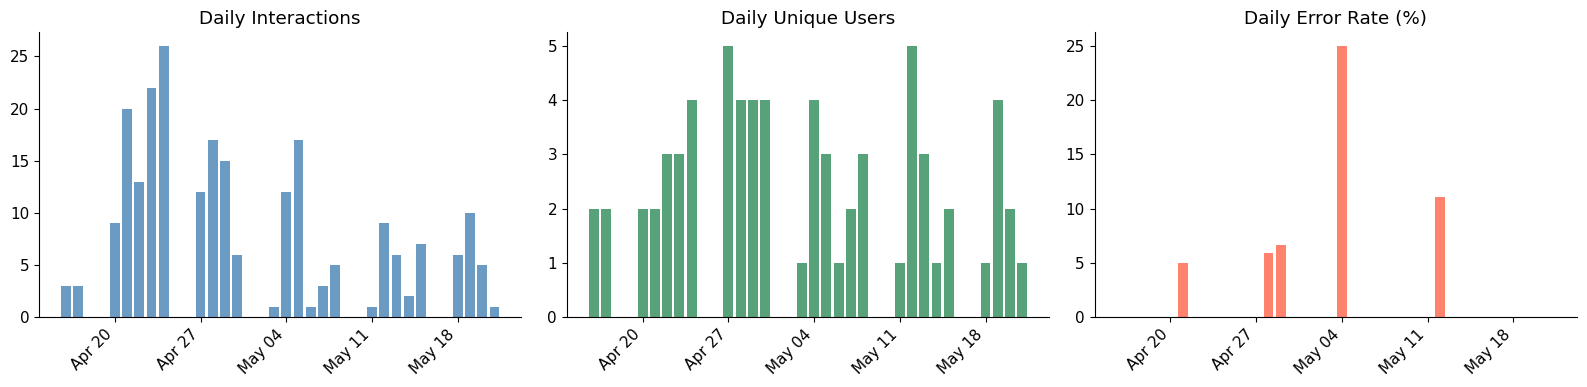

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
dates = pd.to_datetime(daily['date'])

axes[0].bar(dates, daily['total_interactions'], color='steelblue', alpha=0.8)
axes[0].set_title('Daily Interactions')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

axes[1].bar(dates, daily['unique_users'], color='seagreen', alpha=0.8)
axes[1].set_title('Daily Unique Users')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

axes[2].bar(dates, daily['error_rate'], color='tomato', alpha=0.8)
axes[2].set_title('Daily Error Rate (%)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Weekly Snapshots (Slack Format)

In [11]:
weekly = compute_weekly(ix, fb)

DIVIDER = chr(9472) * 52
for _, row in weekly.iterrows():
    print(DIVIDER)
    print(f"📊 Fiona Usage Report - Week of {row['week_label']}")
    print()
    print(f"👤 Unique users: {int(row['unique_users'])}")
    print(f"💬 Sessions: {int(row['sessions'])}")
    print(f"📨 Total interactions: {int(row['total_interactions'])}")
    print(f"⛔ Errors: {int(row['errors'])} ({row['error_rate']}% error rate)")
    print(f"🚫 Rate-limited: {int(row['rate_limited'])}")
    print()
    print(f"👍 Good feedback: {int(row['good_feedback'])}")
    print(f"👎 Bad feedback: {int(row['bad_feedback'])}")
    print(f"📈 Feedback ratio: {row['feedback_ratio']}% positive")
    print(f"📊 Avg interactions/user: {row['avg_per_user']}")
    print(f"📝 Feedback response rate: {row['feedback_response_rate']}%")
    print()
print(DIVIDER)

────────────────────────────────────────────────────
📊 Fiona Usage Report - Week of Apr 13-Apr 19, 2026

👤 Unique users: 4
💬 Sessions: 4
📨 Total interactions: 6
⛔ Errors: 0 (0.0% error rate)
🚫 Rate-limited: 0

👍 Good feedback: 1
👎 Bad feedback: 2
📈 Feedback ratio: 33.3% positive
📊 Avg interactions/user: 1.5
📝 Feedback response rate: 75.0%

────────────────────────────────────────────────────
📊 Fiona Usage Report - Week of Apr 20-Apr 26, 2026

👤 Unique users: 8
💬 Sessions: 15
📨 Total interactions: 90
⛔ Errors: 1 (1.1% error rate)
🚫 Rate-limited: 0

👍 Good feedback: 2
👎 Bad feedback: 0
📈 Feedback ratio: 100.0% positive
📊 Avg interactions/user: 11.2
📝 Feedback response rate: 13.3%

────────────────────────────────────────────────────
📊 Fiona Usage Report - Week of Apr 27-May 3, 2026

👤 Unique users: 13
💬 Sessions: 21
📨 Total interactions: 51
⛔ Errors: 2 (3.9% error rate)
🚫 Rate-limited: 0

👍 Good feedback: 0
👎 Bad feedback: 0
📈 Feedback ratio: 0.0% positive
📊 Avg interactions/user: 3.9
📝 

## Week-over-Week Longitudinal Trends

In [12]:
display(weekly[['week_label', 'unique_users', 'sessions', 'total_interactions',
               'errors', 'error_rate', 'rate_limited', 'good_feedback',
               'bad_feedback', 'feedback_ratio', 'avg_per_user', 'feedback_response_rate']])

,week_label,unique_users,sessions,total_interactions,errors,error_rate,rate_limited,good_feedback,bad_feedback,feedback_ratio,avg_per_user,feedback_response_rate
0,"Apr 13-Apr 19, 2026",4,4,6,0,0.0,0,1,2,33.3,1.5,75.0
1,"Apr 20-Apr 26, 2026",8,15,90,1,1.1,0,2,0,100.0,11.2,13.3
2,"Apr 27-May 3, 2026",13,21,51,2,3.9,0,0,0,0.0,3.9,0.0
3,"May 4-May 10, 2026",11,13,38,3,7.9,0,0,2,0.0,3.5,15.4
4,"May 11-May 17, 2026",8,11,25,1,4.0,0,0,0,0.0,3.1,0.0
5,"May 18-May 24, 2026",7,8,22,0,0.0,0,0,0,0.0,3.1,0.0


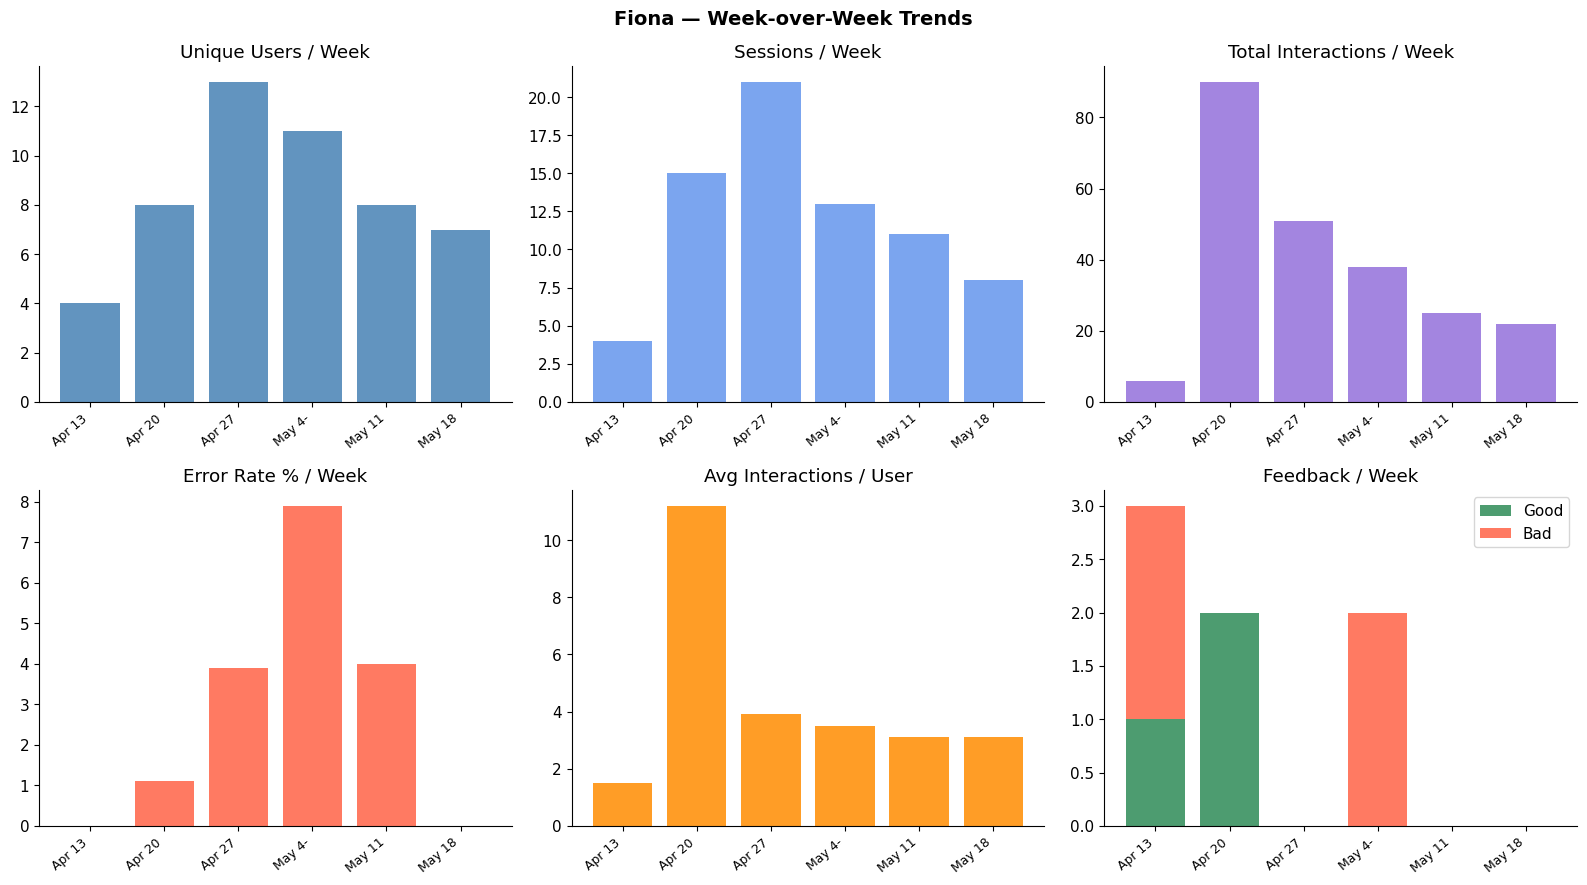

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
week_labels = weekly['week_label'].str[:6]

def bar(ax, col, title, color):
    ax.bar(range(len(weekly)), weekly[col], color=color, alpha=0.85)
    ax.set_title(title)
    ax.set_xticks(range(len(weekly)))
    ax.set_xticklabels(week_labels, rotation=40, ha='right', fontsize=9)

bar(axes[0,0], 'unique_users', 'Unique Users / Week', 'steelblue')
bar(axes[0,1], 'sessions', 'Sessions / Week', 'cornflowerblue')
bar(axes[0,2], 'total_interactions', 'Total Interactions / Week', 'mediumpurple')
bar(axes[1,0], 'error_rate', 'Error Rate % / Week', 'tomato')
bar(axes[1,1], 'avg_per_user', 'Avg Interactions / User', 'darkorange')

# Feedback stacked bar
ax = axes[1,2]
x = range(len(weekly))
ax.bar(x, weekly['good_feedback'], label='Good', color='seagreen', alpha=0.85)
ax.bar(x, weekly['bad_feedback'], bottom=weekly['good_feedback'], label='Bad', color='tomato', alpha=0.85)
ax.set_title('Feedback / Week')
ax.set_xticks(list(x))
ax.set_xticklabels(week_labels, rotation=40, ha='right', fontsize=9)
ax.legend()

plt.suptitle('Fiona — Week-over-Week Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Feedback Details

In [14]:
if len(fb) > 0:
    fb_display = fb[['timestamp', 'userId', 'value', 'userMessage', 'botResponse']].copy()
    fb_display['userMessage'] = fb_display['userMessage'].str[:80]
    fb_display['botResponse'] = fb_display['botResponse'].str[:80]
    display(fb_display.sort_values('timestamp', ascending=False).head(20))
else:
    print('No feedback records found for the selected deployment filter.')

,timestamp,userId,value,userMessage,botResponse
22,2026-05-05 10:26:05.366000-05:00,U8MP4NTLG,bad-feedback,"In 6.2 api, the oauth did not require a year, ...","*Yes, that's correct for v6.2* — OAuth token r..."
21,2026-05-04 16:29:07.760000-05:00,U0ARWT706RY,bad-feedback,What settings would effect the size of the fie...,Thank you for that detail—`varbinary(8000)` is...
20,2026-04-24 16:57:55.349000-05:00,UA0CMFN9G,good-feedback,Please create a table summarizing the new enti...,These new entities primarily decouple demograp...
19,2026-04-24 16:55:07.670000-05:00,UA0CMFN9G,good-feedback,Provide a table listing the Ed-Fi certificatio...,This message contains interactive elements.
18,2026-04-16 17:48:45.560000-05:00,UA0CMFN9G,bad-feedback,tell me about data standard 6.1,*Ed-Fi Data Standard 6.1* is a version of the ...
17,2026-04-16 17:47:41.072000-05:00,U07F6FFAVS9,good-feedback,How do I set up ODS/API version 7.3?,"To set up *Ed-Fi ODS/API v7.3*, you have two m..."
16,2026-04-13 16:31:40.826000-05:00,ULTRM40EN,bad-feedback,can I run API version 7.1 without OdsConnectio...,"*Yes, you can run Ed-Fi API 7.1 without manual..."
15,2026-04-08 11:49:28.004000-05:00,U056L1QEM1U,bad-feedback,Is nhibernate used in edfi one roster,I'm not certain about NHibernate's role in Ed-...
14,2026-04-06 08:40:43.819000-05:00,U07M86DHPDM,good-feedback,<@U0AK7KP5MK6> Describe the key changes to Stu...,"*In Ed-Fi Data Standard 6.0, the StudentEducat..."
13,2026-04-03 15:55:02.919000-05:00,UA0CMFN9G,good-feedback,Describe the key changes to StudentEducationOr...,*StudentEducationOrganizationAssociation (SEOA...


## Top Users by Interaction Count

In [15]:
top_users = ix.groupby('userId').agg(
    interactions=('id', 'count'),
    sessions=('threadTs', 'nunique'),
    errors=('is_error', 'sum'),
    first_seen=('timestamp', 'min'),
    last_seen=('timestamp', 'max'),
).sort_values('interactions', ascending=False).reset_index()
top_users['error_rate'] = (top_users['errors'] / top_users['interactions'] * 100).round(1)
top_users['avg_per_session'] = (top_users['interactions'] / top_users['sessions']).round(1)
display(top_users.head(20))

,userId,interactions,sessions,errors,first_seen,last_seen,error_rate,avg_per_session
0,U8MP4NTLG,103,14,2,2026-04-17 08:17:05.351000-05:00,2026-05-20 14:17:37.330000-05:00,1.9,7.4
1,U03HMGRRA0L,20,1,3,2026-04-21 14:16:18.763000-05:00,2026-05-19 10:11:42.270000-05:00,15.0,20.0
2,U09CX46BSTB,15,4,0,2026-04-24 06:19:51.012000-05:00,2026-04-27 09:08:53.241000-05:00,0.0,3.8
3,ULTRM40EN,11,2,2,2026-04-29 11:39:53.876000-05:00,2026-05-12 12:36:13.649000-05:00,18.2,5.5
4,U07F6FFAVS9,10,4,0,2026-04-16 17:47:16.683000-05:00,2026-05-19 00:11:56.897000-05:00,0.0,2.5
5,U07M86DHPDM,9,4,0,2026-04-30 17:28:38.894000-05:00,2026-05-19 10:28:41.193000-05:00,0.0,2.2
6,UA7S95MU2,8,1,0,2026-04-20 11:16:29.778000-05:00,2026-05-14 10:20:22.755000-05:00,0.0,8.0
7,UA0CMFN9G,7,3,0,2026-04-16 17:48:32.236000-05:00,2026-04-24 16:57:50.355000-05:00,0.0,2.3
8,U010N03S04E,5,1,0,2026-04-17 14:39:52.932000-05:00,2026-05-13 13:25:33.444000-05:00,0.0,5.0
9,U056L1QEM1U,5,3,0,2026-05-07 11:35:31.688000-05:00,2026-05-13 13:52:54.712000-05:00,0.0,1.7


## Export to Excel

In [16]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.chart import BarChart, LineChart, Reference, DoughnutChart

# Prepare dataframes for export
daily_export = daily.copy()
daily_export['date'] = daily_export['date'].astype(str)

weekly_export = weekly[['week_label', 'unique_users', 'sessions', 'total_interactions',
                        'errors', 'error_rate', 'rate_limited', 'good_feedback',
                        'bad_feedback', 'feedback_ratio', 'avg_per_user', 'feedback_response_rate']].copy()

feedback_export = fb[['timestamp', 'userId', 'value', 'userMessage', 'botResponse']].copy() if len(fb) > 0 else pd.DataFrame()
feedback_export['timestamp'] = feedback_export['timestamp'].astype(str)

top_users_export = top_users.copy()
top_users_export['first_seen'] = top_users_export['first_seen'].astype(str)
top_users_export['last_seen'] = top_users_export['last_seen'].astype(str)

# Create Excel file with multiple sheets
excel_file = 'usage-analytics-export.xlsx'
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    daily_export.to_excel(writer, sheet_name='Daily Summary', index=False)
    weekly_export.to_excel(writer, sheet_name='Weekly Trends', index=False)
    if len(feedback_export) > 0:
        feedback_export.to_excel(writer, sheet_name='Feedback', index=False)
    top_users_export.to_excel(writer, sheet_name='Top Users', index=False)
    
    # Add summary stats to first sheet
    summary_df = pd.DataFrame({
        'Metric': ['Total Interactions', 'Unique Users', 'Total Sessions', 'Error Rate (%)', 
                   'Rate Limited Events', 'Good Feedback', 'Bad Feedback'],
        'Value': [
            len(ix),
            ix['userId'].nunique(),
            ix['threadTs'].nunique(),
            (ix['is_error'].sum() / len(ix) * 100).round(1),
            ix['rateLimited'].sum(),
            (fb['is_good'].sum() if len(fb) > 0 else 0),
            (fb['is_bad'].sum() if len(fb) > 0 else 0)
        ]
    })
    summary_df.to_excel(writer, sheet_name='Summary', index=False)

# Format the workbook
wb = openpyxl.load_workbook(excel_file)
header_fill = PatternFill(start_color='366092', end_color='366092', fill_type='solid')
header_font = Font(bold=True, color='FFFFFF')

for sheet in wb.sheetnames:
    ws = wb[sheet]
    # Format headers
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    
    # Auto-fit columns
    for column in ws.columns:
        max_length = 0
        column_letter = column[0].column_letter
        for cell in column:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        adjusted_width = min(max_length + 2, 50)
        ws.column_dimensions[column_letter].width = adjusted_width

# Add charts to Daily Summary sheet
ws_daily = wb['Daily Summary']
chart1 = BarChart()
chart1.type = "col"
chart1.title = "Daily Interactions"
chart1.x_axis.title = "Date"
chart1.y_axis.title = "Count"
data1 = Reference(ws_daily, min_col=4, min_row=1, max_row=len(daily_export)+1)
cats1 = Reference(ws_daily, min_col=1, min_row=2, max_row=len(daily_export)+1)
chart1.add_data(data1, titles_from_data=True)
chart1.set_categories(cats1)
chart1.height = 10
chart1.width = 15
ws_daily.add_chart(chart1, "F2")

chart2 = BarChart()
chart2.type = "col"
chart2.title = "Daily Unique Users"
chart2.x_axis.title = "Date"
chart2.y_axis.title = "Users"
data2 = Reference(ws_daily, min_col=2, min_row=1, max_row=len(daily_export)+1)
chart2.add_data(data2, titles_from_data=True)
chart2.set_categories(cats1)
chart2.height = 10
chart2.width = 15
ws_daily.add_chart(chart2, "F20")

chart3 = LineChart()
chart3.title = "Daily Error Rate (%)"
chart3.x_axis.title = "Date"
chart3.y_axis.title = "Error Rate %"
data3 = Reference(ws_daily, min_col=6, min_row=1, max_row=len(daily_export)+1)
chart3.add_data(data3, titles_from_data=True)
chart3.set_categories(cats1)
chart3.height = 10
chart3.width = 15
ws_daily.add_chart(chart3, "F38")

# Add charts to Weekly Trends sheet
ws_weekly = wb['Weekly Trends']
chart4 = BarChart()
chart4.type = "col"
chart4.title = "Unique Users / Week"
chart4.x_axis.title = "Week"
chart4.y_axis.title = "Users"
data4 = Reference(ws_weekly, min_col=2, min_row=1, max_row=len(weekly_export)+1)
cats4 = Reference(ws_weekly, min_col=1, min_row=2, max_row=len(weekly_export)+1)
chart4.add_data(data4, titles_from_data=True)
chart4.set_categories(cats4)
chart4.height = 10
chart4.width = 15
ws_weekly.add_chart(chart4, "G2")

chart5 = BarChart()
chart5.type = "col"
chart5.title = "Total Interactions / Week"
chart5.x_axis.title = "Week"
chart5.y_axis.title = "Interactions"
data5 = Reference(ws_weekly, min_col=4, min_row=1, max_row=len(weekly_export)+1)
chart5.add_data(data5, titles_from_data=True)
chart5.set_categories(cats4)
chart5.height = 10
chart5.width = 15
ws_weekly.add_chart(chart5, "G20")

chart6 = LineChart()
chart6.title = "Error Rate % / Week"
chart6.x_axis.title = "Week"
chart6.y_axis.title = "Error Rate %"
data6 = Reference(ws_weekly, min_col=6, min_row=1, max_row=len(weekly_export)+1)
chart6.add_data(data6, titles_from_data=True)
chart6.set_categories(cats4)
chart6.height = 10
chart6.width = 15
ws_weekly.add_chart(chart6, "G38")

# Add feedback pie chart if data exists
if len(feedback_export) > 0:
    ws_feedback = wb['Feedback']
    # Create summary of feedback values
    feedback_counts = fb['value'].value_counts()
    ws_feedback['H2'] = 'Feedback Summary'
    row = 3
    for val, count in feedback_counts.items():
        ws_feedback[f'H{row}'] = val
        ws_feedback[f'I{row}'] = count
        row += 1
    
    chart_pie = DoughnutChart()
    chart_pie.title = "Feedback Distribution"
    labels = Reference(ws_feedback, min_col=8, min_row=4, max_row=row-1)
    data_pie = Reference(ws_feedback, min_col=9, min_row=3, max_row=row-1)
    chart_pie.add_data(data_pie, titles_from_data=True)
    chart_pie.set_categories(labels)
    chart_pie.height = 10
    chart_pie.width = 15
    ws_feedback.add_chart(chart_pie, "G2")

# Add top users chart
ws_top = wb['Top Users']
chart7 = BarChart()
chart7.type = "col"
chart7.title = "Top 10 Users by Interaction Count"
chart7.x_axis.title = "User ID"
chart7.y_axis.title = "Interactions"
data7 = Reference(ws_top, min_col=2, min_row=1, max_row=min(11, len(top_users_export)+1))
cats7 = Reference(ws_top, min_col=1, min_row=2, max_row=min(11, len(top_users_export)+1))
chart7.add_data(data7, titles_from_data=True)
chart7.set_categories(cats7)
chart7.height = 10
chart7.width = 15
ws_top.add_chart(chart7, "G2")

wb.save(excel_file)
print(f"✅ Exported to {excel_file}")
print(f"Sheets: {', '.join(wb.sheetnames)}")
print(f"📊 Added charts to Daily Summary, Weekly Trends, Top Users, and Feedback sheets")

✅ Exported to usage-analytics-export.xlsx
Sheets: Daily Summary, Weekly Trends, Feedback, Top Users, Summary
📊 Added charts to Daily Summary, Weekly Trends, Top Users, and Feedback sheets


## Generate Executive Report (Markdown & PDF)

In [17]:
from datetime import datetime
from pathlib import Path

from reportlab.lib import colors
from reportlab.lib.pagesizes import letter, landscape
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, PageBreak, Image
from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY
from xml.sax.saxutils import escape

# -----------------------------
# Build section data
# -----------------------------

kpi = {
    "total_interactions": len(ix),
    "unique_users": ix["userId"].nunique(),
    "total_sessions": ix["threadTs"].nunique(),
    "error_rate": (ix["is_error"].sum() / len(ix) * 100) if len(ix) > 0 else 0.0,
    "rate_limited_events": int(ix["rateLimited"].sum()) if "rateLimited" in ix.columns else 0,
}

if len(fb) > 0:
    kpi["good_feedback"] = int(fb["is_good"].sum())
    kpi["bad_feedback"] = int(fb["is_bad"].sum())
else:
    kpi["good_feedback"] = 0
    kpi["bad_feedback"] = 0

feedback_total = kpi["good_feedback"] + kpi["bad_feedback"]
kpi["feedback_sentiment"] = (kpi["good_feedback"] / feedback_total * 100) if feedback_total > 0 else 0.0
kpi["avg_interactions_per_user"] = (kpi["total_interactions"] / kpi["unique_users"]) if kpi["unique_users"] > 0 else 0.0

# Week-over-week longitudinal trends
week_over_week = weekly[
    [
        "week_label",
        "unique_users",
        "sessions",
        "total_interactions",
        "errors",
        "error_rate",
        "good_feedback",
        "bad_feedback",
        "feedback_ratio",
        "avg_per_user",
        "feedback_response_rate",
    ]
].copy()

week_over_week["users_wow_pct"] = week_over_week["unique_users"].pct_change().mul(100).round(1)
week_over_week["interactions_wow_pct"] = week_over_week["total_interactions"].pct_change().mul(100).round(1)
week_over_week["error_rate_wow_pp"] = week_over_week["error_rate"].diff().round(1)

# Weekly snapshots (already summarized by week)
weekly_snapshots = weekly[
    [
        "week_label",
        "unique_users",
        "sessions",
        "total_interactions",
        "errors",
        "error_rate",
        "rate_limited",
        "good_feedback",
        "bad_feedback",
        "feedback_ratio",
        "avg_per_user",
        "feedback_response_rate",
    ]
].copy()

# Daily summary
daily_summary = daily[
    ["date", "unique_users", "sessions", "total_interactions", "errors", "rate_limited", "error_rate"]
].copy()

# Feedback details
if len(fb) > 0:
    feedback_details = fb[["timestamp", "userId", "value", "userMessage", "botResponse"]].copy()
    feedback_details = feedback_details.sort_values("timestamp", ascending=False)
else:
    feedback_details = pd.DataFrame(columns=["timestamp", "userId", "value", "userMessage", "botResponse"])

# Top users by feedback volume
if len(fb) > 0:
    top_users_feedback = (
        fb.groupby("userId")
        .agg(
            feedback_count=("feedbackId", "count"),
            good_feedback=("is_good", "sum"),
            bad_feedback=("is_bad", "sum"),
            last_feedback=("timestamp", "max"),
        )
        .reset_index()
        .sort_values("feedback_count", ascending=False)
    )
    top_users_feedback["positive_ratio_pct"] = (
        top_users_feedback["good_feedback"]
        .div(top_users_feedback["feedback_count"].replace(0, np.nan))
        .mul(100)
        .fillna(0)
        .round(1)
    )
else:
    top_users_feedback = pd.DataFrame(
        columns=["userId", "feedback_count", "good_feedback", "bad_feedback", "last_feedback", "positive_ratio_pct"]
    )

# Top users by interaction count (reuse computed table)
top_users_interactions = top_users[
    ["userId", "interactions", "sessions", "errors", "error_rate", "avg_per_session", "first_seen", "last_seen"]
].copy()

# -----------------------------
# PDF-friendly shaping for crowded columns
# -----------------------------

def to_compact_ts(value):
    try:
        return pd.to_datetime(value).strftime("%Y-%m-%d %H:%M")
    except Exception:
        return str(value)


def compact_week_label(label):
    text = str(label)
    try:
        start, rest = text.split('-', 1)
        end_part, year = rest.rsplit(',', 1)
        end_day = end_part.strip().split(' ')[-1]
        return f"{start}-{end_day},{year}"
    except Exception:
        return text


def truncate_text(value, limit):
    text = "" if pd.isna(value) else str(value)
    return text if len(text) <= limit else text[: limit - 3] + "..."


feedback_details_pdf = feedback_details.copy()
if len(feedback_details_pdf) > 0:
    feedback_details_pdf["timestamp"] = feedback_details_pdf["timestamp"].apply(to_compact_ts)
    feedback_details_pdf["userMessage"] = feedback_details_pdf["userMessage"].apply(lambda x: truncate_text(x, 80))
    feedback_details_pdf["botResponse"] = feedback_details_pdf["botResponse"].apply(lambda x: truncate_text(x, 220))

top_users_interactions_pdf = top_users_interactions.copy()
if len(top_users_interactions_pdf) > 0:
    top_users_interactions_pdf["first_seen"] = top_users_interactions_pdf["first_seen"].apply(to_compact_ts)
    top_users_interactions_pdf["last_seen"] = top_users_interactions_pdf["last_seen"].apply(to_compact_ts)

top_users_feedback_pdf = top_users_feedback.copy()
if len(top_users_feedback_pdf) > 0:
    top_users_feedback_pdf["last_feedback"] = top_users_feedback_pdf["last_feedback"].apply(to_compact_ts)

week_over_week_pdf = week_over_week.copy()
if len(week_over_week_pdf) > 0:
    week_over_week_pdf['week_label'] = week_over_week_pdf['week_label'].apply(compact_week_label)
    week_over_week_pdf['unique_users'] = week_over_week_pdf['unique_users'].apply(lambda x: f"{int(x):,}")
week_over_week_pdf = week_over_week_pdf.rename(columns={
    'week_label': 'week',
    'unique_users': 'users',
    'total_interactions': 'interactions',
    'error_rate': 'err%',
    'good_feedback': 'good_fb',
    'bad_feedback': 'bad_fb',
    'feedback_ratio': 'pos%',
    'avg_per_user': 'avg/user',
    'feedback_response_rate': 'fb_resp%',
    'users_wow_pct': 'users_wow%',
    'interactions_wow_pct': 'int_wow%',
    'error_rate_wow_pp': 'err_wow_pp',
})

weekly_snapshots_pdf = weekly_snapshots.copy()
if len(weekly_snapshots_pdf) > 0:
    weekly_snapshots_pdf['week_label'] = weekly_snapshots_pdf['week_label'].apply(compact_week_label)
    weekly_snapshots_pdf['unique_users'] = weekly_snapshots_pdf['unique_users'].apply(lambda x: f"{int(x):,}")
weekly_snapshots_pdf = weekly_snapshots_pdf.rename(columns={
    'week_label': 'week',
    'unique_users': 'users',
    'total_interactions': 'interactions',
    'error_rate': 'err%',
    'rate_limited': 'rate_lmt',
    'good_feedback': 'good_fb',
    'bad_feedback': 'bad_fb',
    'feedback_ratio': 'pos%',
    'avg_per_user': 'avg/user',
    'feedback_response_rate': 'fb_resp%',
})

# -----------------------------
# Build chart assets (matplotlib)
# -----------------------------

assets_dir = Path("report_assets")
assets_dir.mkdir(parents=True, exist_ok=True)

daily_chart_path = assets_dir / "daily_summary.png"
weekly_chart_path = assets_dir / "weekly_trends.png"
feedback_chart_path = assets_dir / "feedback_distribution.png"
top_users_chart_path = assets_dir / "top_users_interactions.png"

# Daily summary visual
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
dates = pd.to_datetime(daily["date"]) if len(daily) > 0 else pd.Series([], dtype="datetime64[ns]")

if len(daily) > 0:
    axes[0].bar(dates, daily["total_interactions"], color="steelblue", alpha=0.85)
    axes[0].set_title("Daily Interactions")
    axes[1].bar(dates, daily["unique_users"], color="seagreen", alpha=0.85)
    axes[1].set_title("Daily Unique Users")
    axes[2].bar(dates, daily["error_rate"], color="tomato", alpha=0.85)
    axes[2].set_title("Daily Error Rate (%)")

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
else:
    for ax in axes:
        ax.text(0.5, 0.5, "No daily data", ha="center", va="center")

plt.suptitle("Fiona Daily Summary", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(daily_chart_path, dpi=180, bbox_inches="tight")
plt.close(fig)

# Weekly trend visual
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
week_labels = weekly["week_label"].str[:6] if len(weekly) > 0 else pd.Series([], dtype="object")

if len(weekly) > 0:
    def bar(ax, col, title, color):
        ax.bar(range(len(weekly)), weekly[col], color=color, alpha=0.85)
        ax.set_title(title)
        ax.set_xticks(range(len(weekly)))
        ax.set_xticklabels(week_labels, rotation=40, ha="right", fontsize=9)

    bar(axes[0, 0], "unique_users", "Unique Users / Week", "steelblue")
    bar(axes[0, 1], "sessions", "Sessions / Week", "cornflowerblue")
    bar(axes[0, 2], "total_interactions", "Interactions / Week", "mediumpurple")
    bar(axes[1, 0], "error_rate", "Error Rate % / Week", "tomato")
    bar(axes[1, 1], "avg_per_user", "Avg Interactions / User", "darkorange")

    x = range(len(weekly))
    axes[1, 2].bar(x, weekly["good_feedback"], label="Good", color="seagreen", alpha=0.85)
    axes[1, 2].bar(x, weekly["bad_feedback"], bottom=weekly["good_feedback"], label="Bad", color="tomato", alpha=0.85)
    axes[1, 2].set_title("Feedback / Week")
    axes[1, 2].set_xticks(list(x))
    axes[1, 2].set_xticklabels(week_labels, rotation=40, ha="right", fontsize=9)
    axes[1, 2].legend()
else:
    for ax in axes.flatten():
        ax.text(0.5, 0.5, "No weekly data", ha="center", va="center")

plt.suptitle("Fiona Week-over-Week Trends", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(weekly_chart_path, dpi=180, bbox_inches="tight")
plt.close(fig)

# Feedback distribution visual
fig, ax = plt.subplots(figsize=(6, 4))
if feedback_total > 0:
    vals = [kpi["good_feedback"], kpi["bad_feedback"]]
    labels = ["Good", "Bad"]
    colors_fb = ["seagreen", "tomato"]
    ax.pie(vals, labels=labels, autopct="%1.1f%%", startangle=120, colors=colors_fb)
    ax.set_title("Feedback Distribution")
else:
    ax.text(0.5, 0.5, "No feedback data", ha="center", va="center")
    ax.set_title("Feedback Distribution")
fig.savefig(feedback_chart_path, dpi=180, bbox_inches="tight")
plt.close(fig)

# Top users by interactions visual
fig, ax = plt.subplots(figsize=(10, 4))
if len(top_users_interactions) > 0:
    top10 = top_users_interactions.head(10)
    x = np.arange(len(top10))
    ax.bar(x, top10["interactions"], color="steelblue", alpha=0.85)
    ax.set_title("Top 10 Users by Interaction Count")
    ax.set_ylabel("Interactions")
    ax.set_xticks(x)
    ax.set_xticklabels(top10["userId"].astype(str), rotation=45, ha="right", fontsize=8)
else:
    ax.text(0.5, 0.5, "No top-user data", ha="center", va="center")
    ax.set_title("Top 10 Users by Interaction Count")
fig.savefig(top_users_chart_path, dpi=180, bbox_inches="tight")
plt.close(fig)


# -----------------------------
# Helpers
# -----------------------------

def df_to_markdown_table(df, max_rows=20):
    if df is None or len(df) == 0:
        return "_No data available._"
    sample = df.head(max_rows).copy()
    sample = sample.fillna("")
    cols = list(sample.columns)
    header = "| " + " | ".join(cols) + " |"
    sep = "| " + " | ".join(["---"] * len(cols)) + " |"
    rows = [
        "| " + " | ".join(str(sample.iloc[i][c]).replace("\n", " ") for c in cols) + " |"
        for i in range(len(sample))
    ]
    return "\n".join([header, sep] + rows)


def format_for_pdf(df, max_rows=12):
    if df is None or len(df) == 0:
        return [["No data available"]]
    sample = df.head(max_rows).copy().fillna("")
    cols = [str(c) for c in sample.columns]
    data = [cols]
    for i in range(len(sample)):
        data.append([str(sample.iloc[i][c]) for c in sample.columns])
    return data


# -----------------------------
# Markdown report
# -----------------------------

week_over_week_md = week_over_week.copy()
weekly_snapshots_md = weekly_snapshots.copy()
daily_summary_md = daily_summary.copy()
feedback_details_md = feedback_details.copy()
top_users_feedback_md = top_users_feedback.copy()
top_users_interactions_md = top_users_interactions.copy()

for df in [week_over_week_md, weekly_snapshots_md]:
    if 'week_label' in df.columns:
        df['week_label'] = df['week_label'].apply(compact_week_label)
    if 'unique_users' in df.columns:
        df['unique_users'] = df['unique_users'].apply(lambda x: f"{int(x):,}")

if len(feedback_details_md) > 0 and 'timestamp' in feedback_details_md.columns:
    feedback_details_md['timestamp'] = feedback_details_md['timestamp'].apply(to_compact_ts)

if len(top_users_interactions_md) > 0:
    if 'first_seen' in top_users_interactions_md.columns:
        top_users_interactions_md['first_seen'] = top_users_interactions_md['first_seen'].apply(to_compact_ts)
    if 'last_seen' in top_users_interactions_md.columns:
        top_users_interactions_md['last_seen'] = top_users_interactions_md['last_seen'].apply(to_compact_ts)
    if 'interactions' in top_users_interactions_md.columns:
        top_users_interactions_md['interactions'] = top_users_interactions_md['interactions'].apply(lambda x: f"{int(x):,}")

if len(top_users_feedback_md) > 0 and 'last_feedback' in top_users_feedback_md.columns:
    top_users_feedback_md['last_feedback'] = top_users_feedback_md['last_feedback'].apply(to_compact_ts)

report_ts = datetime.now().strftime("%B %d, %Y at %I:%M %p")

markdown_report = f"""# Fiona Usage Analytics Executive Report

**Report Generated:** {report_ts}

## Executive Summary

Fiona shows strong engagement and stable performance. This report is organized to align directly with the analysis notebook sections.

### KPI Snapshot

| Metric | Value |
|---|---|
| Total Interactions | {kpi['total_interactions']:,} |
| Unique Users | {kpi['unique_users']:,} |
| Total Sessions | {kpi['total_sessions']:,} |
| Average Interactions per User | {kpi['avg_interactions_per_user']:.1f} |
| System Error Rate | {kpi['error_rate']:.1f}% |
| Rate-Limited Events | {kpi['rate_limited_events']:,} |
| Positive Feedback | {kpi['feedback_sentiment']:.1f}% |

## Week-over-Week Longitudinal Trends

![Week-over-Week Trends](report_assets/weekly_trends.png)

{df_to_markdown_table(week_over_week_md, max_rows=20)}

## Weekly Snapshots

{df_to_markdown_table(weekly_snapshots_md, max_rows=20)}

## Daily Summary

![Daily Summary](report_assets/daily_summary.png)

{df_to_markdown_table(daily_summary_md, max_rows=31)}

## Feedback Details

![Feedback Distribution](report_assets/feedback_distribution.png)

{df_to_markdown_table(feedback_details_md, max_rows=25)}

## Top Users by Feedback

{df_to_markdown_table(top_users_feedback_md, max_rows=20)}

## Top Users by Interaction Count

![Top Users by Interaction Count](report_assets/top_users_interactions.png)

{df_to_markdown_table(top_users_interactions_md, max_rows=20)}

## Executive Notes

1. User engagement remains healthy, with consistent weekly usage and repeat sessions.
2. Error rates should continue to be monitored week-over-week with attention to spikes.
3. Feedback concentration by user can help target enablement and support efforts.
4. High-interaction users are prime candidates for qualitative follow-up.
"""

md_filename = "fiona-executive-report.md"
with open(md_filename, "w", encoding="utf-8") as f:
    f.write(markdown_report)
print(f"Saved markdown report: {md_filename}")


# -----------------------------
# PDF report (Landscape)
# -----------------------------

pdf_filename = "fiona-executive-report.pdf"
doc = SimpleDocTemplate(
    pdf_filename,
    pagesize=landscape(letter),
    leftMargin=0.4 * inch,
    rightMargin=0.4 * inch,
    topMargin=0.4 * inch,
    bottomMargin=0.4 * inch,
)
styles = getSampleStyleSheet()
story = []

# Custom styles
cover_title = ParagraphStyle(
    "CoverTitle",
    parent=styles["Heading1"],
    fontSize=22,
    textColor=colors.HexColor("#1a5490"),
    alignment=TA_CENTER,
    spaceAfter=10,
)
section_title = ParagraphStyle(
    "SectionTitle",
    parent=styles["Heading2"],
    fontSize=13,
    textColor=colors.HexColor("#366092"),
    spaceBefore=8,
    spaceAfter=6,
)
body = ParagraphStyle(
    "Body",
    parent=styles["BodyText"],
    fontSize=10,
    alignment=TA_JUSTIFY,
    spaceAfter=5,
)

story.append(Paragraph("FIONA USAGE ANALYTICS", cover_title))
story.append(Paragraph("Executive Report", styles["Heading3"]))
story.append(Paragraph(f"Generated: {report_ts}", styles["Normal"]))
story.append(Spacer(1, 0.2 * inch))

story.append(Paragraph("Executive Summary", section_title))
story.append(
    Paragraph(
        "This document mirrors the notebook sections so executive stakeholders can review trend, usage, reliability, and feedback outcomes in one place.",
        body,
    )
)

kpi_table = Table(
    [
        ["Metric", "Value"],
        ["Total Interactions", f"{kpi['total_interactions']:,}"],
        ["Unique Users", f"{kpi['unique_users']:,}"],
        ["Total Sessions", f"{kpi['total_sessions']:,}"],
        ["Average Interactions per User", f"{kpi['avg_interactions_per_user']:.1f}"],
        ["System Error Rate", f"{kpi['error_rate']:.1f}%"],
        ["Rate-Limited Events", f"{kpi['rate_limited_events']:,}"],
        ["Positive Feedback", f"{kpi['feedback_sentiment']:.1f}%"],
    ],
    colWidths=[3.1 * inch, 2.2 * inch],
)
kpi_table.setStyle(
    TableStyle(
        [
            ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#366092")),
            ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
            ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
            ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
            ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#f5f7fa")]),
            ("FONTSIZE", (0, 0), (-1, -1), 9),
        ]
    )
)
story.append(kpi_table)
story.append(PageBreak())


def add_section_table(title, df, max_rows=12, col_weights=None, wrap_cols=None, wrap_limit=240):
    if title:
        story.append(Paragraph(title, section_title))

    table_data = format_for_pdf(df, max_rows=max_rows)

    if wrap_cols:
        wrap_style = ParagraphStyle('TableWrap', parent=styles['BodyText'], fontSize=7, leading=8)
        for r in range(1, len(table_data)):
            for c in wrap_cols:
                if c < len(table_data[r]):
                    txt = '' if table_data[r][c] is None else str(table_data[r][c])
                    if len(txt) > wrap_limit:
                        txt = txt[: wrap_limit - 3] + '...'
                    txt = escape(txt).replace('\n', '<br/>')
                    table_data[r][c] = Paragraph(txt, wrap_style)
    col_count = len(table_data[0])
    usable_width = doc.pagesize[0] - doc.leftMargin - doc.rightMargin

    if col_weights and len(col_weights) == col_count:
        weight_sum = sum(col_weights)
        col_widths = [usable_width * (w / weight_sum) for w in col_weights]
    else:
        col_width = usable_width / max(col_count, 1)
        col_widths = [col_width] * col_count

    tbl = Table(table_data, repeatRows=1, colWidths=col_widths)
    tbl.setStyle(
        TableStyle(
            [
                ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#366092")),
                ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
                ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
                ("FONTSIZE", (0, 0), (-1, -1), 7.5),
                ("GRID", (0, 0), (-1, -1), 0.35, colors.lightgrey),
                ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#f9fbfd")]),
                ("VALIGN", (0, 0), (-1, -1), "TOP"),
            ]
        )
    )
    story.append(tbl)
    story.append(Spacer(1, 0.15 * inch))


def add_pdf_image(path, width=None):
    if Path(path).exists():
        max_width = doc.pagesize[0] - doc.leftMargin - doc.rightMargin
        final_width = width if width is not None else min(max_width, 7.8 * inch)
        final_width = min(final_width, max_width)

        img = Image(str(path))
        ratio = img.imageHeight / img.imageWidth if img.imageWidth else 0.5
        img.drawWidth = final_width
        img.drawHeight = final_width * ratio
        story.append(img)
        story.append(Spacer(1, 0.12 * inch))


story.append(Paragraph("Week-over-Week Longitudinal Trends", section_title))
add_pdf_image(weekly_chart_path)
add_section_table("", week_over_week_pdf, max_rows=14, col_weights=[1.9, 1.0, 1.0, 1.25, 0.8, 0.8, 0.8, 0.8, 0.8, 0.95, 0.95, 0.95, 0.95, 1.1])

story.append(Paragraph("Weekly Snapshots", section_title))
add_section_table("", weekly_snapshots_pdf, max_rows=14, col_weights=[2.0, 1.1, 1.0, 1.35, 0.9, 0.9, 0.9, 0.9, 0.9, 1.0, 1.0, 1.1])

story.append(Paragraph("Daily Summary", section_title))
add_pdf_image(daily_chart_path)
add_section_table("", daily_summary, max_rows=20)

story.append(PageBreak())
story.append(Paragraph("Feedback Details", section_title))
add_pdf_image(feedback_chart_path, width=4.0 * inch)
add_section_table("", feedback_details_pdf, max_rows=14, col_weights=[1.5, 1.1, 0.9, 1.8, 4.7], wrap_cols=[3, 4], wrap_limit=220)

story.append(Paragraph("Top Users by Feedback", section_title))
add_section_table("", top_users_feedback_pdf, max_rows=14)

story.append(Paragraph("Top Users by Interaction Count", section_title))
add_pdf_image(top_users_chart_path)
add_section_table("", top_users_interactions_pdf, max_rows=14, col_weights=[1.2, 0.8, 0.8, 0.7, 0.9, 1.2, 1.7, 1.7])

story.append(Paragraph("Executive Notes", section_title))
story.append(Paragraph("1. Engagement remains steady with meaningful repeat usage patterns.", body))
story.append(Paragraph("2. Weekly trend monitoring should remain focused on error-rate movement and interaction growth.", body))
story.append(Paragraph("3. Feedback-heavy users and high-interaction users can guide targeted support and training.", body))

doc.build(story)
print(f"Saved PDF report: {pdf_filename}")
print(f"Saved chart assets in: {assets_dir}")
print("Executive markdown and PDF reports now include targeted column sizing for crowded fields.")

Saved markdown report: fiona-executive-report.md
Saved PDF report: fiona-executive-report.pdf
Saved chart assets in: report_assets
Executive markdown and PDF reports now include targeted column sizing for crowded fields.
